In [6]:
import os
import glob
import numpy as np
from scipy import stats
from collections import defaultdict
from pyubx2 import UBXReader
import warnings
# Suppress polyfit rank warnings
warnings.simplefilter('ignore', np.exceptions.RankWarning)
# --- Constants ---
TARGET_EPOCHS = 100
CYCLE_SLIP_THRESH = 50.0
MS_TO_METERS = 299_792_458.0 / 1000.0
MAX_TARGET_SATS = 6
NUM_FEATURES = 13
POLY_ORDER = 3
CONSTELLATION_MAP = {"1077": "GPS", "1127": "BDS"}
ACCEPTED_SIGNALS  = {"1077": {"1C"}, "1127": {"2I", "1X"}}
NAV_GNSS_MAP      = {0: "GPS", 3: "BDS"}
# --- Core Functions ---
def _key(constellation, prn):
    return f"{constellation}_{int(prn):03d}"
def extract_13_features(signal):
    if len(signal) == 0: return np.zeros(NUM_FEATURES)
    mean, var, std = np.mean(signal), np.var(signal), np.std(signal)
    max_val, min_val = np.max(signal), np.min(signal)
    ptp_range, median = max_val - min_val, np.median(signal)
    iqr = np.percentile(signal, 75) - np.percentile(signal, 25)
    skew = stats.skew(signal) if var > 1e-10 else 0.0
    kurt = stats.kurtosis(signal) if var > 1e-10 else 0.0
    rms = np.sqrt(np.mean(signal**2))
    mad = np.mean(np.abs(signal - mean))
    energy = np.sum(signal**2)
    return np.array([mean, var, std, max_val, min_val, ptp_range, median, iqr, skew, kurt, rms, mad, energy])
def parse_rtcm(filepath):
    with open(filepath, "rb") as f:
        elevations = {}
        phases = defaultdict(list)
        ubr = UBXReader(f)
        for _raw, parsed in ubr:
            if parsed is None: continue
            mid = parsed.identity
            if mid == "NAV-SAT":
                for i in range(1, getattr(parsed, "numSvs", 0) + 1):
                    g, s = getattr(parsed, f"gnssId_{i:02d}", -1), getattr(parsed, f"svId_{i:02d}", 0)
                    e = getattr(parsed, f"elev_{i:02d}", -91)
                    if NAV_GNSS_MAP.get(g) and e != -91: elevations[_key(NAV_GNSS_MAP[g], s)] = e
            elif mid in CONSTELLATION_MAP:
                n_sat, n_cell = getattr(parsed, "NSat", 0), getattr(parsed, "NCell", 0)
                if n_sat == 0 or n_cell == 0: continue
                rough = {getattr(parsed, f"PRN_{s:02d}"): getattr(parsed, f"DF398_{s:02d}") 
                         for s in range(1, n_sat + 1) if getattr(parsed, f"PRN_{s:02d}", None)}
                for c in range(1, n_cell + 1):
                    prn, sig, fpr = getattr(parsed, f"CELLPRN_{c:02d}", None), getattr(parsed, f"CELLSIG_{c:02d}", None), getattr(parsed, f"DF406_{c:02d}", None)
                    if prn and fpr and prn in rough and sig in ACCEPTED_SIGNALS[mid]:
                        phases[_key(CONSTELLATION_MAP[mid], prn)].append((rough[prn] + fpr) * MS_TO_METERS)
    return elevations, dict(phases)
def process_file_finesat(filepath):
    elevations, phases = parse_rtcm(filepath)
    good_sats = []
    for k in phases:
        arr = np.array(phases[k][:TARGET_EPOCHS])
        if len(arr) == TARGET_EPOCHS and int(np.sum(np.abs(np.diff(arr)) > CYCLE_SLIP_THRESH)) == 0:
            good_sats.append((k, elevations.get(k, -91)))
    good_sats.sort(key=lambda x: x[1], reverse=True)
    if len(good_sats) < 2: return None 
        
    ref_key = good_sats[0][0]
    ref_signal = np.array(phases[ref_key][:TARGET_EPOCHS])
    t = np.linspace(0, 10, TARGET_EPOCHS)
    target_keys = [k for k, _ in good_sats[1:MAX_TARGET_SATS + 1]]
    
    sample_features = []
    for i in range(MAX_TARGET_SATS):
        if i < len(target_keys):
            tgt_signal = np.array(phases[target_keys[i]][:TARGET_EPOCHS])
            diff_signal = tgt_signal - ref_signal
            trend = np.polyval(np.polyfit(t, diff_signal, POLY_ORDER), t)
            finesat_signal = diff_signal - trend
            sample_features.extend(extract_13_features(finesat_signal))
        else:
            sample_features.extend(np.zeros(NUM_FEATURES))
    return np.array(sample_features)
# --- Execution ---
files = glob.glob("samples/*.rtcm")
X, Y = [], []
print(f"Processing {len(files)} files...")
for f in files:
    label = os.path.basename(f).split('-')[0]
    features = process_file_finesat(f)
    if features is not None:
        X.append(features)
        Y.append(label)
X = np.array(X)
Y = np.array(Y)
print(f"Done! X Shape: {X.shape}, Y Shape: {Y.shape}")

Processing 50 files...
Done! X Shape: (50, 78), Y Shape: (50,)


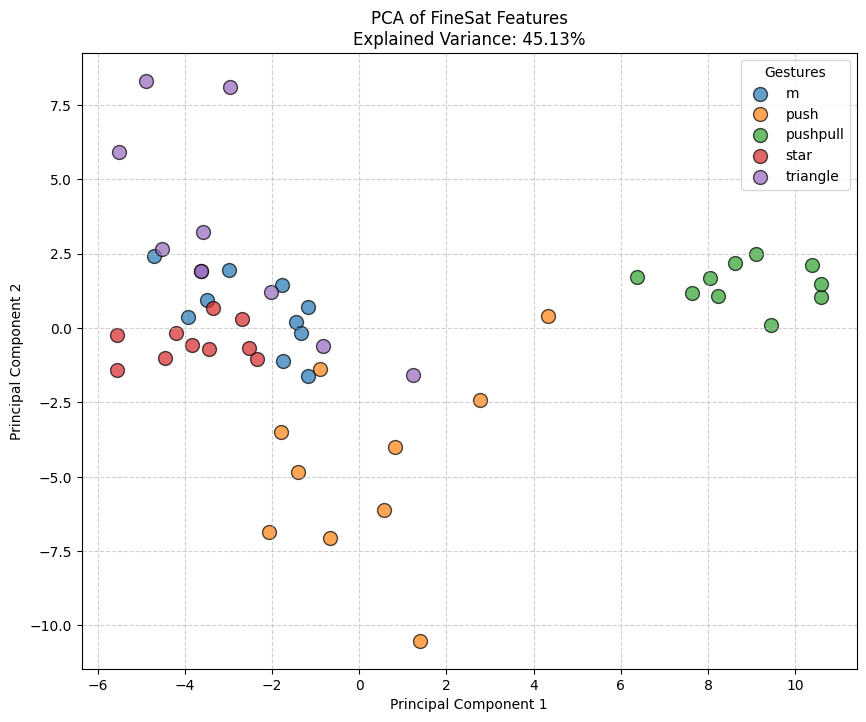

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Run PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Plotting
plt.figure(figsize=(10, 8))
unique_labels = np.unique(Y)
for label in unique_labels:
    idx = (Y == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, s=100, alpha=0.7, edgecolors='k')
plt.title(f"PCA of FineSat Features\nExplained Variance: {pca.explained_variance_ratio_.sum():.2%}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Gestures")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.70
Fold 2: Accuracy = 1.00
Fold 3: Accuracy = 0.70
Fold 4: Accuracy = 0.80
Fold 5: Accuracy = 0.90

Average Accuracy: 0.82 ± 0.12


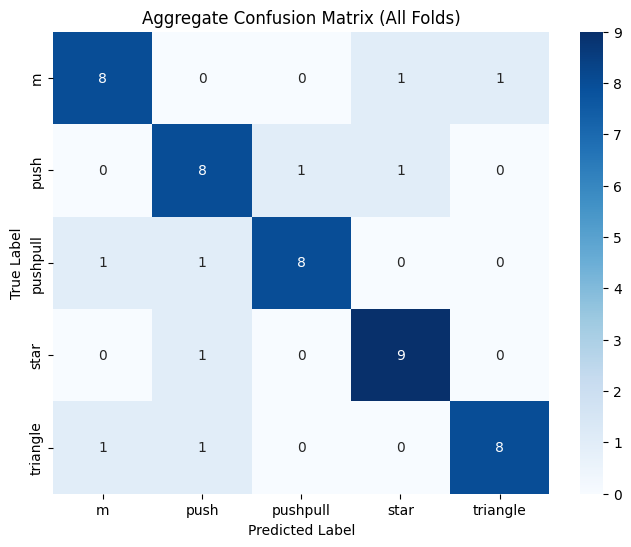

In [8]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
# Convert String labels to Integers for XGBoost
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
# To aggregate confusion matrix over all folds
cm_total = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X, Y_encoded)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = Y_encoded[train_idx], Y_encoded[test_idx]
    
    # Simple default XGBoost model
    model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    accuracies.append(acc)
    
    cm = confusion_matrix(y_test, preds, labels=range(len(le.classes_)))
    cm_total += cm
    
    print(f"Fold {fold+1}: Accuracy = {acc:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies):.2f} ± {np.std(accuracies):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total, annot=True, fmt='g', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

/var/folders/rn/5h9g_tdj74g09p_pb9txttkh0000gn/T/ipykernel_26013/3828635394.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='magma')


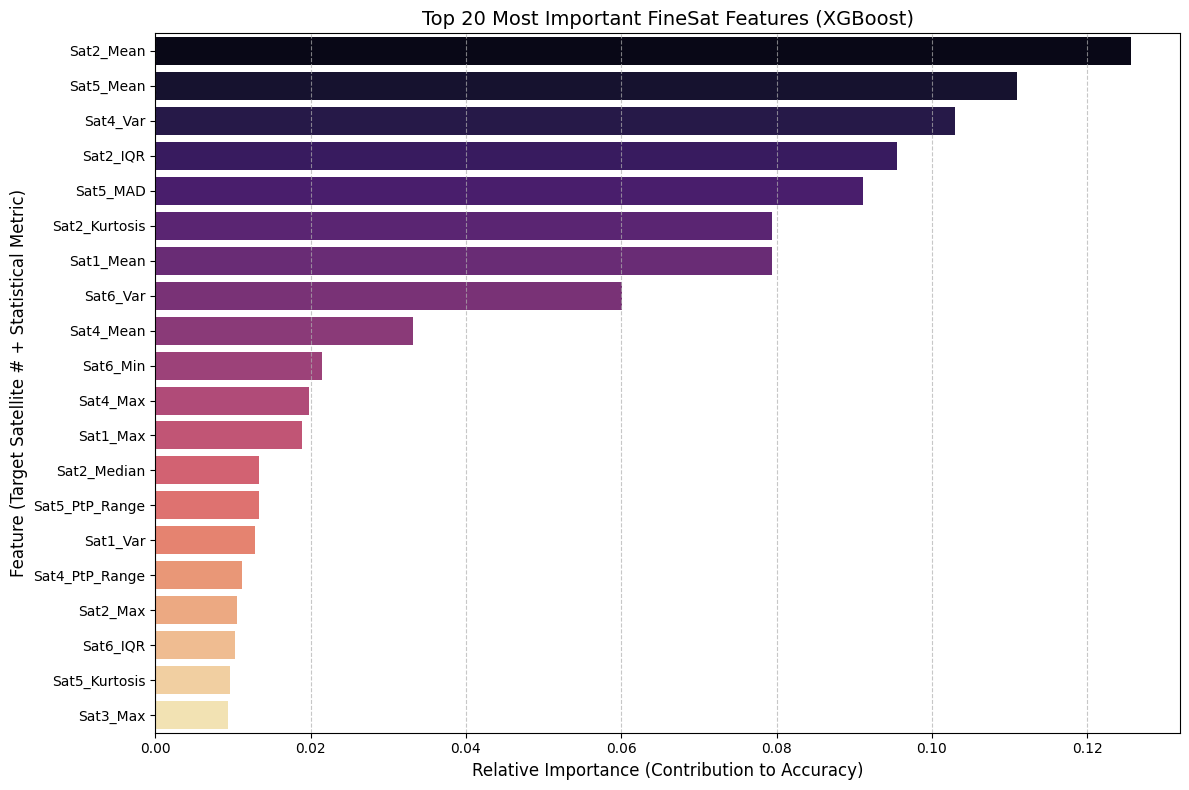

In [9]:
import pandas as pd
# 1. Recreate the human-readable feature names
feature_types = [
    'Mean', 'Var', 'Std', 'Max', 'Min', 'PtP_Range', 
    'Median', 'IQR', 'Skew', 'Kurtosis', 'RMS', 'MAD', 'Energy'
]
feature_names = []
for sat_num in range(1, MAX_TARGET_SATS + 1):
    for f_type in feature_types:
        feature_names.append(f"Sat{sat_num}_{f_type}")
# 2. Extract importances from the model (using the model from the last CV fold)
importances = model.feature_importances_
# 3. Create a DataFrame to easily sort them
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
# Sort to get the Top 20 most important features
top_20_features = importance_df.sort_values(by='Importance', ascending=False).head(20)
# 4. Plot the results
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_20_features, palette='magma')
plt.title('Top 20 Most Important FineSat Features (XGBoost)', fontsize=14)
plt.xlabel('Relative Importance (Contribution to Accuracy)', fontsize=12)
plt.ylabel('Feature (Target Satellite # + Statistical Metric)', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()